In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import ExtraTreesClassifier

# --- 1. SETUP & LOADING ---
input_file    = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smotenc(hybrid70-30)/merged.csv'
output_folder = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smotenc(hybrid70-30)'
output_csv    = os.path.join(output_folder, 'preprocessed_dataset_with_shadow.csv')

os.makedirs(output_folder, exist_ok=True)
print(f"🚀 Loading master dataset: {input_file}")

df = pd.read_csv(input_file, engine='c', low_memory=True)
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype('float32')

print(f"📊 Initial shape: {df.shape}")
print(f"📋 Columns: {df.shape[1]} | Rows: {df.shape[0]:,}")

label_col = [c for c in df.columns if c.lower() == 'label'][0]

# --- 2. SUPERCLASS MAPPING ---
label_mapping = {
    'DDOS-ICMP_FLOOD': 'DDoS', 'DDOS-UDP_FLOOD': 'DDoS', 'DDOS-TCP_FLOOD': 'DDoS',
    'DDOS-PSHACK_FLOOD': 'DDoS', 'DDOS-SYN_FLOOD': 'DDoS', 'DDOS-RSTFINFLOOD': 'DDoS',
    'DDOS-SYNONYMOUSIP_FLOOD': 'DDoS', 'DDOS-UDP_FRAGMENTATION': 'DDoS', 'DDOS-ACK_FRAGMENTATION': 'DDoS',
    'DDOS-ICMP_FRAGMENTATION': 'DDoS', 'DDOS-HTTP_FLOOD': 'DDoS',
    'DOS-UDP_FLOOD': 'DoS', 'DOS-TCP_FLOOD': 'DoS', 'DOS-SYN_FLOOD': 'DoS', 'DOS-HTTP_FLOOD': 'DoS',
    'MIRAI-GREETH_FLOOD': 'Mirai', 'MIRAI-UDPPLAIN': 'Mirai', 'MIRAI-GREIP_FLOOD': 'Mirai',
    'RECON-HOSTDISCOVERY': 'Recon', 'RECON-OSSCAN': 'Recon', 'RECON-PORTSCAN': 'Recon', 'RECON-PINGSWEEP': 'Recon',
    'VULNERABILITYSCAN': 'Recon', 'SQLINJECTION': 'Web-based', 'BACKDOOR_MALWARE': 'Web-based',
    'XSS': 'Web-based', 'BROWSERHIJACKING': 'Web-based', 'COMMANDINJECTION': 'Web-based',
    'UPLOADING_ATTACK': 'Web-based', 'DNS_SPOOFING': 'Spoofing', 'MITM-ARPSPOOFING': 'Spoofing',
    'DICTIONARYBRUTEFORCE': 'Brute Force', 'BENIGN': 'Benign'
}

print("\n🧹 Mapping superclasses and creating binary labels...")
df['Superclass'] = df[label_col].astype(str).str.strip().str.upper().map(label_mapping)
df['Binary_Label'] = df['Superclass'].apply(lambda x: 0 if x == 'Benign' else 1)

print(f"\n📊 Class Distribution (Fine-grained):")
print(df[label_col].value_counts().to_string())
print(f"\n📊 Superclass Distribution:")
print(df['Superclass'].value_counts().to_string())
print(f"\n📊 Binary Label Distribution:")
print(df['Binary_Label'].value_counts().rename({0: 'Benign (0)', 1: 'Attack (1)'}).to_string())


🚀 Loading master dataset: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smotenc(hybrid70-30)/merged.csv
📊 Initial shape: (2788653, 40)
📋 Columns: 40 | Rows: 2,788,653

🧹 Mapping superclasses and creating binary labels...

📊 Class Distribution (Fine-grained):
label
BENIGN                     988049
DDOS-UDP_FRAGMENTATION      67509
DOS-SYN_FLOOD               67470
DDOS-TCP_FLOOD              67449
DOS-TCP_FLOOD               67445
DNS_SPOOFING                67438
DDOS-ACK_FRAGMENTATION      67430
DOS-UDP_FLOOD               67419
DDOS-UDP_FLOOD              67418
MIRAI-GREETH_FLOOD          67416
VULNERABILITYSCAN           67416
DDOS-RSTFINFLOOD            67409
DDOS-SYN_FLOOD              67392
MIRAI-UDPPLAIN              67391
RECON-PORTSCAN              67389
RECON-HOSTDISCOVERY         67380
MIRAI-GREIP_FLOOD           67379
DDOS-SYNONYMOUSIP_FLOOD     67371
RECON-OSSCAN                67363
DDOS-ICMP_FRAGMENTATION     67357
DDOS-ICMP_FLOOD             67343
DDOS-PSHAC

In [3]:
# --- 3. CLEANING ---
print("\n🧹 Handling Infinity and NaN values...")
before_nan = df.isnull().sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
numeric_cols = df.select_dtypes(include=[np.number]).columns
imputed = 0
for col in numeric_cols:
    if col not in ['Binary_Label'] and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
        imputed += 1
after_nan = df.isnull().sum().sum()
print(f"  ✅ Columns imputed with median: {imputed}")
print(f"  ✅ NaN values before: {before_nan:,} → after: {after_nan:,}")

# --- 4. VARIANCE THRESHOLD ---
print("\n🔍 Applying Variance Threshold (removing features with < 1% variance)...")

# Explicitly exclude 'number' — synthetic binary artifact in CICIoT2023
# (assigns exactly 10 packets to low-volume attacks, 100 to flood attacks)
# This creates a near-perfect class separator that does not reflect real
# network traffic variability and would dominate feature importance unfairly.
EXCLUDE_FEATURES = ['number']
X_raw = df.drop(columns=[label_col, 'Superclass', 'Binary_Label'] + EXCLUDE_FEATURES)
y_bin = df['Binary_Label']
print(f"  ℹ️  Manually excluded: {EXCLUDE_FEATURES} (synthetic dataset artifact)")

selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X_raw)
active_features  = X_raw.columns[selector.get_support()].tolist()
dropped_var_cols = X_raw.columns[~selector.get_support()].tolist()
dropped_var      = len(X_raw.columns) - len(active_features)
print(f"  ✂️ Features before: {len(X_raw.columns)} | Dropped: {dropped_var} | Remaining: {len(active_features)}")
print(f"  📋 Dropped by variance threshold:")
for col in dropped_var_cols:
    print(f"     - {col} (variance: {X_raw[col].var():.6f})")

# --- 5. EXTRA TREES IMPORTANCE (run BEFORE correlation filter) ---
print("\n🏆 Ranking features using Extra Trees BEFORE correlation filter...")
X_var_df  = pd.DataFrame(X_var, columns=active_features)
model_fs  = ExtraTreesClassifier(n_estimators=30, random_state=42, n_jobs=-1)
model_fs.fit(X_var_df, y_bin)
feat_importances = pd.Series(model_fs.feature_importances_, index=active_features)

# --- 6. IMPORTANCE-AWARE CORRELATION FILTER ---
print("\n🔗 Removing highly correlated features (> 0.85), keeping more important one...")
corr_matrix = X_var_df.corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    if col in to_drop:
        continue
    correlated_with = upper[col][upper[col] > 0.85].index.tolist()
    for partner in correlated_with:
        if partner in to_drop:
            continue
        if feat_importances[col] >= feat_importances[partner]:
            to_drop.add(partner)
            dropped, kept = partner, col
        else:
            to_drop.add(col)
            dropped, kept = col, partner
        print(f"     - Dropping '{dropped}' (imp: {feat_importances[dropped]:.6f}) "
              f"| Keeping '{kept}' (imp: {feat_importances[kept]:.6f}) "
              f"| corr: {corr_matrix.loc[col, partner]:.4f}")

X_filtered = X_var_df.drop(columns=list(to_drop))
print(f"  ✂️ Features before: {len(active_features)} | "
      f"Dropped: {len(to_drop)} | Remaining: {len(X_filtered.columns)}")

# --- 7. SELECT TOP 15 ---
print(f"\n📌 Top 15 Most Predictive Features (from importance-filtered set):")
feat_importances_filtered = feat_importances[X_filtered.columns]
top_25 = feat_importances_filtered.nlargest(15).index.tolist()
for i, (feat, imp) in enumerate(feat_importances_filtered.nlargest(15).items(), 1):
    print(f"  {i:>2}. {feat:<40} importance: {imp:.6f}")

print(f"\n🗑️  Dropped by Top-15 cutoff:")
dropped_et = feat_importances_filtered.nsmallest(len(X_filtered.columns) - 15)
for feat, imp in dropped_et.sort_values(ascending=False).items():
    print(f"     - {feat:<40} importance: {imp:.6f}")

# --- 8. NO SCALING (XGBoost is invariant to monotonic feature transformations) ---
# RobustScaler was removed because:
# (a) XGBoost uses threshold-based splits — scaling does not affect classification
# (b) Independent per-feature scaling destroys inter-feature ordinal relationships
#     (e.g. min ≤ avg ≤ max) which are valid in raw space but violated after scaling
# (c) A2PM adversarial constraint enforcement requires raw feature space
print("\n⚖️  No scaling applied — XGBoost is scale-invariant (tree-based model).")
print("   Inter-feature ordinal constraints preserved in raw feature space.")

processed_df = X_filtered[top_25].copy()
processed_df['Fine_Label']   = df[label_col].values
processed_df['Binary_Label'] = y_bin.values
processed_df['Superclass']   = df['Superclass'].values

# --- 9. REMOVE DUPLICATES ---
print("\n🧹 Removing duplicate rows...")
before_dedup = len(processed_df)
processed_df = processed_df.drop_duplicates().reset_index(drop=True)
after_dedup  = len(processed_df)
print(f"  ✅ Rows before: {before_dedup:,} | "
      f"Duplicates removed: {before_dedup - after_dedup:,} | "
      f"Rows after: {after_dedup:,}")


processed_df.to_csv(output_csv, index=False)

print(f"\n🎉 SUCCESS!")
print(f"  📐 Final Dataset Shape : {processed_df.shape}")
print(f"  💾 Saved to            : {output_csv}")
print(f"\n{'='*55}")
print(f"  Initial features       : {len(X_raw.columns) + len(EXCLUDE_FEATURES)}")
print(f"  Manually excluded      : {EXCLUDE_FEATURES}")
print(f"  After variance filter  : {len(active_features)}")
print(f"  After correlation filter: {len(X_filtered.columns)}")
print(f"  Final (Top 15)         : 15")
print(f"  Scaling applied        : None (XGBoost scale-invariant)")
print(f"  Duplicates removed     : {before_dedup - after_dedup:,}")
print(f"{'='*55}")


🧹 Handling Infinity and NaN values...
  ✅ Columns imputed with median: 3
  ✅ NaN values before: 29,094 → after: 28,870

🔍 Applying Variance Threshold (removing features with < 1% variance)...
  ℹ️  Manually excluded: ['number'] (synthetic dataset artifact)
  ✂️ Features before: 38 | Dropped: 12 | Remaining: 26
  📋 Dropped by variance threshold:
     - ece_flag_number (variance: 0.000032)
     - cwr_flag_number (variance: 0.000016)
     - dns (variance: 0.003842)
     - telnet (variance: 0.000004)
     - smtp (variance: 0.000004)
     - ssh (variance: 0.001467)
     - irc (variance: 0.000008)
     - dhcp (variance: 0.000171)
     - arp (variance: 0.003414)
     - igmp (variance: 0.000016)
     - ipv (variance: 0.003416)
     - llc (variance: 0.003416)

🏆 Ranking features using Extra Trees BEFORE correlation filter...

🔗 Removing highly correlated features (> 0.85), keeping more important one...
     - Dropping 'syn_count' (imp: 0.015419) | Keeping 'syn_flag_number' (imp: 0.021594) | co

In [4]:
import pandas as pd

file_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smotenc(hybrid70-30)/preprocessed_dataset_with_shadow.csv'
df = pd.read_csv(file_path, low_memory=False)

if 'Fine_Label' in df.columns:
    df['Fine_Label'] = df['Fine_Label'].astype('category')

duplicate_count = df.duplicated().sum()

print(f"📊 Total Rows        : {len(df):,}")
print(f"✨ Duplicate Rows    : {duplicate_count:,}")
print(f"📝 Unique Rows       : {len(df) - duplicate_count:,}")

if duplicate_count > 0:
    print(f"\n⚠️ Warning: {duplicate_count:,} duplicates still found — dropping now...")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"  ✅ Cleaned rows: {len(df):,}")

📊 Total Rows        : 2,782,400
✨ Duplicate Rows    : 0
📝 Unique Rows       : 2,782,400


In [3]:
import time
import joblib
import os
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score, recall_score, accuracy_score

def evaluate_edge_model_detailed(model, name, X_test, y_test, superclasses):
    # 1. Inference timing
    start_inf = time.time()
    y_pred = model.predict(X_test)
    end_inf = time.time()

    total_inference_time_s = end_inf - start_inf
    avg_latency_ms         = (total_inference_time_s / len(X_test)) * 1000
    throughput             = len(X_test) / total_inference_time_s

    # 2. Binary Metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fnr      = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0
    fpr      = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred) * 100

    # 3. Superclass Breakdown
    results_df = pd.DataFrame({'Actual': superclasses.values, 'Pred': y_pred})

    print(f"\n🔍 Detailed Breakdown for {name}:")
    breakdown = []
    for cat in results_df['Actual'].unique():
        subset  = results_df[results_df['Actual'] == cat]
        total   = len(subset)
        correct = (subset['Pred'] == 0).sum() if cat == 'Benign' else (subset['Pred'] == 1).sum()
        rate    = (correct / total) * 100 if total > 0 else 0
        breakdown.append({
            "Superclass": cat,
            "Samples": total,
            "Detection Rate": f"{rate:.2f}%",
            "Missed": total - correct
        })
    print(pd.DataFrame(breakdown).sort_values("Samples", ascending=False).to_string(index=False))

    # 4. Model Size
    model_filename = f"{name.strip().replace(' ', '_').lower()}.pkl"
    joblib.dump(model, model_filename)
    size_kb = os.path.getsize(model_filename) / 1024

    print(f"  ⏱️  Total Inference Time : {total_inference_time_s:.4f}s")
    print(f"  ⚡  Throughput           : {throughput:,.0f} samples/sec")
    print(f"  🎯  Accuracy             : {accuracy:.4f}%")

    return {
        "Model"               : name.strip(),
        "Accuracy (%)"        : round(accuracy, 4),
        "F1-Score"            : round(f1_score(y_test, y_pred), 4),
        "Recall (DR)"         : round(recall_score(y_test, y_pred), 4),
        "FNR"                 : f"{fnr:.3f}%",
        "FPR"                 : f"{fpr:.3f}%",
        "Latency (ms)"        : round(avg_latency_ms, 6),
        "Throughput (samp/s)" : round(throughput, 2),
        "Inference Time (s)"  : round(total_inference_time_s, 4),
        "Size (KB)"           : round(size_kb, 2)
    }

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

processed_df = pd.read_csv('/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smotenc(hybrid70-30)/preprocessed_dataset_with_shadow.csv')

X        = processed_df.drop(columns=['Binary_Label', 'Superclass', 'Fine_Label'])
y_binary = processed_df['Binary_Label']
y_fine   = processed_df['Fine_Label']
s        = processed_df['Superclass']

# Stratify on Fine_Label (34 classes) → guarantees every subclass is exactly 80/20
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y_binary, s, test_size=0.2,
    stratify=y_fine,
    random_state=42
)

print(f"✅ Train size : {len(X_train):,}")
print(f"✅ Test size  : {len(X_test):,}")
print(f"\nTrain Binary Distribution:\n{y_train.value_counts().to_string()}")
print(f"\nTest Binary Distribution:\n{y_test.value_counts().to_string()}")

models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Naïve Bayes"         : GaussianNB(),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),
    "Extra Trees"         : ExtraTreesClassifier(n_estimators=50, max_depth=10, n_jobs=-1),
    "AdaBoost"            : AdaBoostClassifier(n_estimators=50),
    "XGBoost"             : XGBClassifier(n_estimators=50, max_depth=6, verbosity=0),
    "LightGBM"            : lgb.LGBMClassifier(n_estimators=50, learning_rate=0.1, verbose=-1),
}

master_results = []
for name, model in models.items():
    print(f"\n🚀 Training: {name}...")
    model.fit(X_train, y_train)
    res = evaluate_edge_model_detailed(model, name, X_test, y_test, s_test)
    master_results.append(res)

print("\n" + "="*100)
print("MASTER PERFORMANCE COMPARISON")
print("="*100)
print(pd.DataFrame(master_results).sort_values(by="F1-Score", ascending=False).to_string(index=False))

✅ Train size : 2,225,920
✅ Test size  : 556,480

Train Binary Distribution:
Binary_Label
1    1435842
0     790078

Test Binary Distribution:
Binary_Label
1    358960
0    197520

🚀 Training: Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



🔍 Detailed Breakdown for Logistic Regression:
 Superclass  Samples Detection Rate  Missed
     Benign   197520         83.11%   33371
       DDoS   139841         99.98%      27
      Recon    59609         63.90%   21521
        DoS    46014         99.99%       3
      Mirai    40406         99.96%      17
  Web-based    34630         75.55%    8466
   Spoofing    26920         48.12%   13965
Brute Force     5766         72.25%    1600
        NaN        0          0.00%       0
  ⏱️  Total Inference Time : 0.0465s
  ⚡  Throughput           : 11,955,061 samples/sec
  🎯  Accuracy             : 85.8090%

🚀 Training: Naïve Bayes...

🔍 Detailed Breakdown for Naïve Bayes:
 Superclass  Samples Detection Rate  Missed
     Benign   197520         97.82%    4305
       DDoS   139841         86.43%   18976
      Recon    59609          8.64%   54458
        DoS    46014         70.24%   13695
      Mirai    40406         99.94%      23
  Web-based    34630          8.36%   31736
   Spoofing  

In [7]:
import pandas as pd

# Reconstruct full label series aligned with the split
full_fine = processed_df['Fine_Label']

# Get train and test indices from the split
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    processed_df.index,
    test_size=0.2,
    stratify=processed_df['Fine_Label'],
    random_state=42
)

train_counts = processed_df.loc[train_idx, 'Fine_Label'].value_counts().sort_index()
test_counts  = processed_df.loc[test_idx,  'Fine_Label'].value_counts().sort_index()

summary = pd.DataFrame({
    'Train': train_counts,
    'Test':  test_counts,
    'Total': train_counts + test_counts,
    'Train %': (train_counts / (train_counts + test_counts) * 100).round(2),
    'Test %':  (test_counts  / (train_counts + test_counts) * 100).round(2),
}).sort_values('Total', ascending=False)

print(f"{'='*65}")
print(f"{'Class':<30} {'Train':>8} {'Test':>8} {'Train%':>8} {'Test%':>7}")
print(f"{'='*65}")
for label, row in summary.iterrows():
    print(f"{str(label):<30} {int(row['Train']):>8,} {int(row['Test']):>8,} {row['Train %']:>7.2f}% {row['Test %']:>6.2f}%")
print(f"{'='*65}")
print(f"{'TOTAL':<30} {train_counts.sum():>8,} {test_counts.sum():>8,}")

Class                             Train     Test   Train%   Test%
BENIGN                          820,924  205,231   80.00%  20.00%
DDOS-ICMP_FRAGMENTATION          55,994   13,998   80.00%  20.00%
VULNERABILITYSCAN                55,993   13,999   80.00%  20.00%
DDOS-ACK_FRAGMENTATION           55,987   13,997   80.00%  20.00%
DDOS-UDP_FRAGMENTATION           55,978   13,995   80.00%  20.00%
RECON-HOSTDISCOVERY              55,975   13,994   80.00%  20.00%
MIRAI-GREIP_FLOOD                55,970   13,993   80.00%  20.00%
MIRAI-GREETH_FLOOD               55,966   13,991   80.00%  20.00%
DNS_SPOOFING                     55,946   13,987   80.00%  20.00%
MIRAI-UDPPLAIN                   55,928   13,982   80.00%  20.00%
MITM-ARPSPOOFING                 55,922   13,980   80.00%  20.00%
DOS-UDP_FLOOD                    55,882   13,970   80.00%  20.00%
RECON-OSSCAN                     55,863   13,966   80.00%  20.00%
DDOS-ICMP_FLOOD                  55,844   13,961   80.00%  20.00%
DDOS-UDP_F

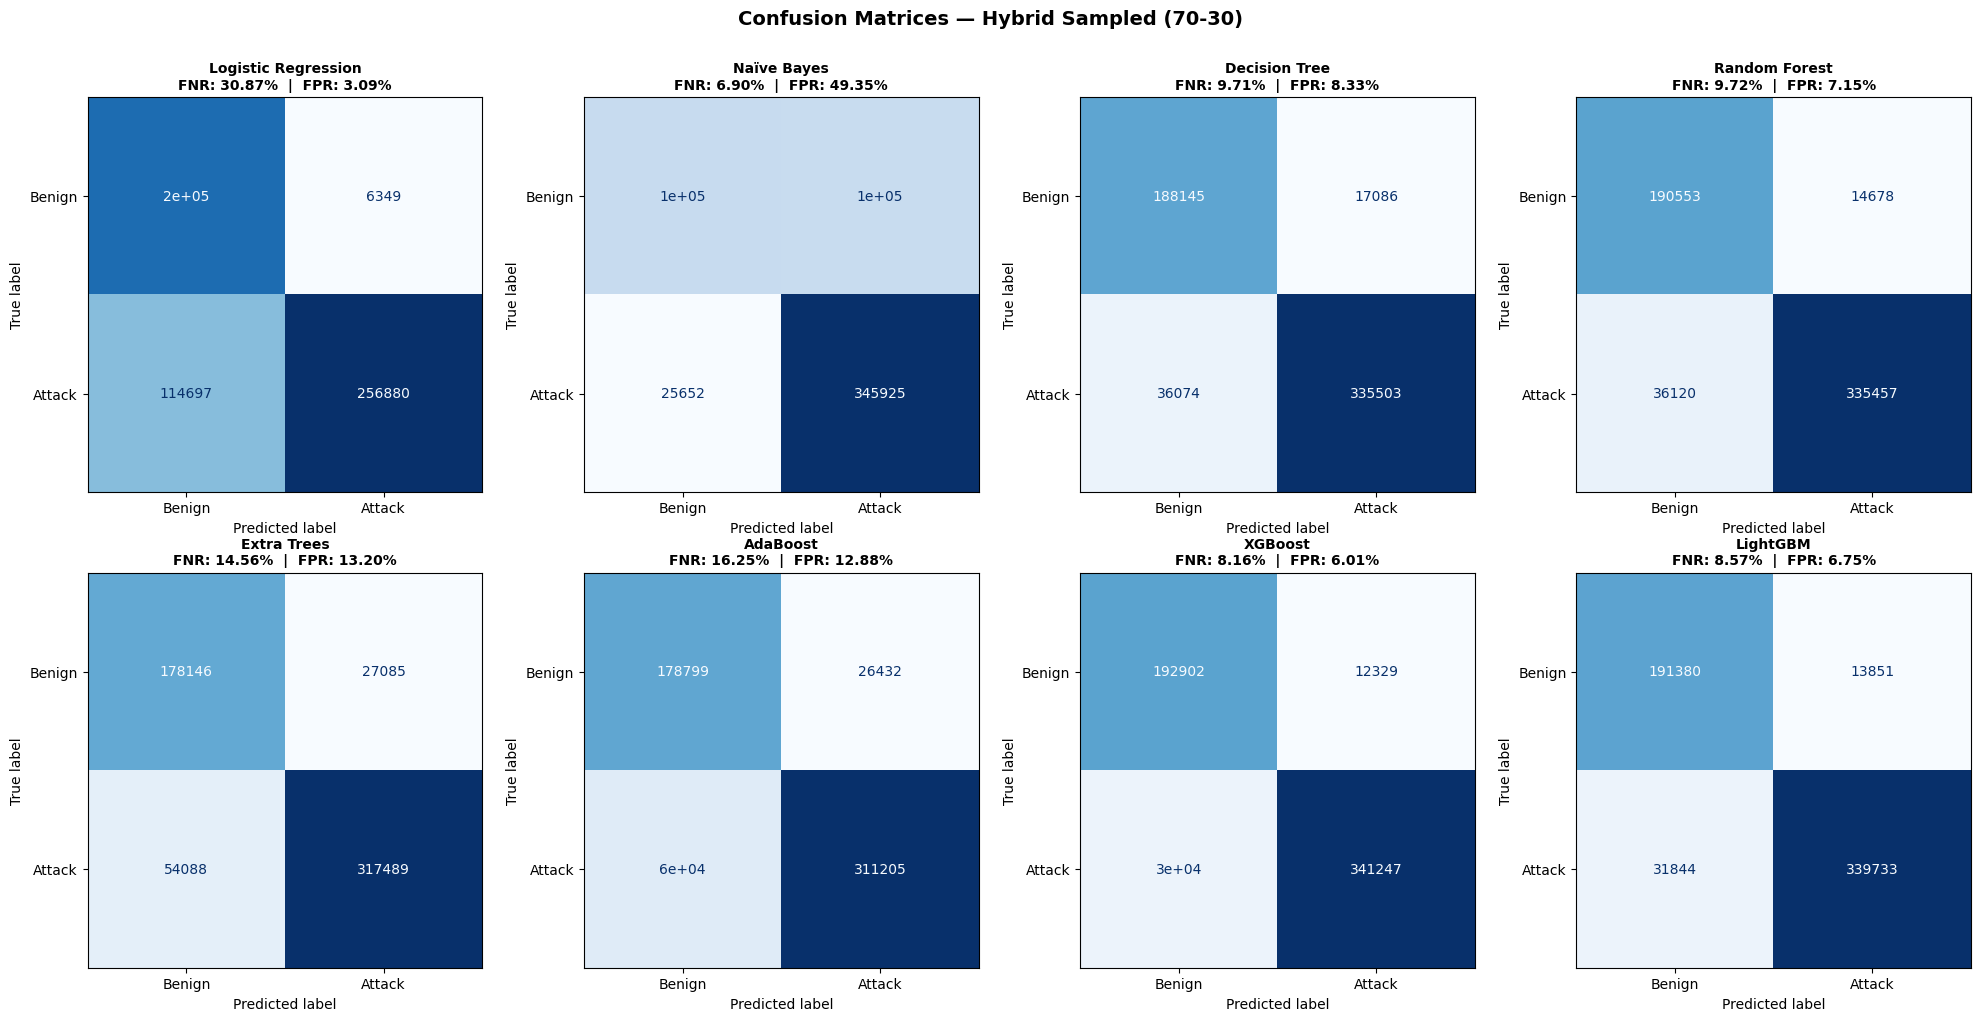

In [8]:
# ─── Confusion Matrices — Hybrid Sampled (70-30) ────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Benign', 'Attack']
    )
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')

    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0
    fpr = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0

    axes[i].set_title(
        f'{name}\nFNR: {fnr:.2f}%  |  FPR: {fpr:.2f}%',
        fontsize=10, fontweight='bold'
    )

fig.suptitle('Confusion Matrices — Hybrid Sampled (70-30)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()